In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat0 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_lrg_north_1.0.0_basic.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_lrg_north_1.0.0_photom.fits'))
pz = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_lrg_north_1.0.0_pz_new.fits'))
lrgmask = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_lrg_north_1.0.0_lrgmask_v1.fits'))
cat = hstack([cat0, cat, pz, lrgmask], join_type='exact')
print(len(cat))

3194955


In [6]:
# maskbits = [1, 8, 9, 11, 12, 13]

# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print(np.sum(~mask_clean)/len(mask_clean))
# cat = cat[mask_clean]
# print(len(cat))

0.1149537317427006
2827683


In [4]:
mask_clean = cat['lrg_mask']==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

0.14188494047646993
2741639


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.

In [6]:
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag'])

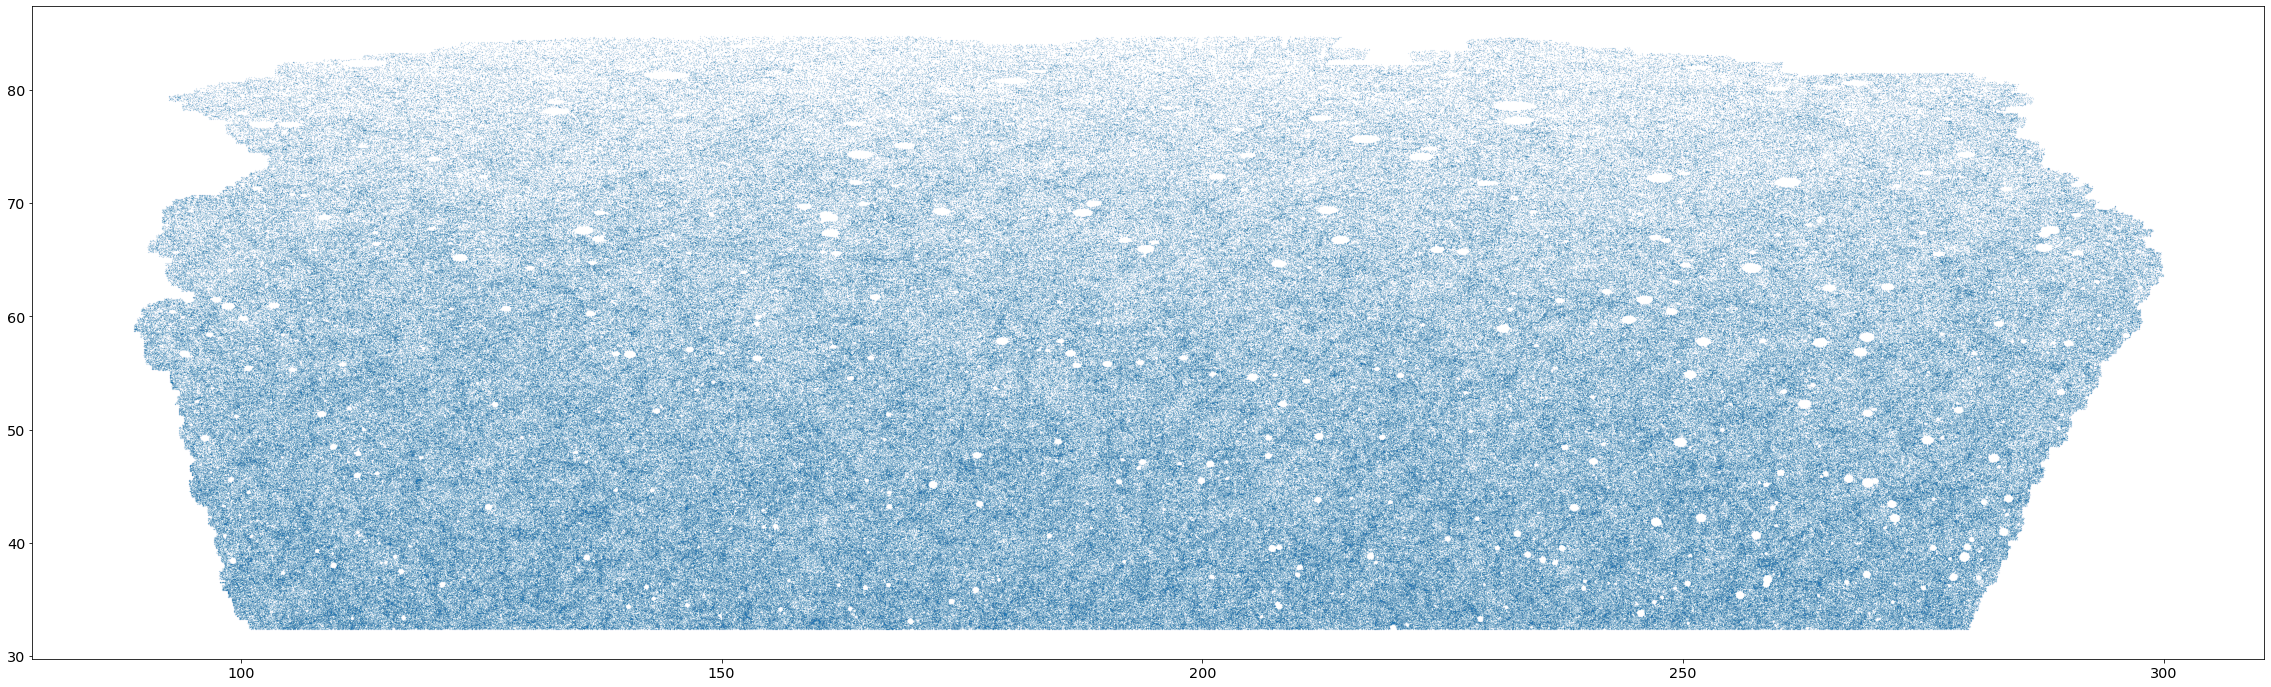

In [7]:
plt.figure(figsize=(40, 12))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.2, alpha=0.5)
# plt.axis([360, 0, -30, 35])
plt.show()

In [8]:
mask = (cat['Z_PHOT_MEDIAN']>0.4) & (cat['Z_PHOT_MEDIAN']<1.1)
np.percentile(cat['Z_PHOT_MEDIAN'][mask], [0.001, 20, 40, 60, 80, 99.9])

array([0.40001558, 0.58620715, 0.70955437, 0.81573451, 0.88920736,
       1.09549544])

In [9]:
# pz_min_all, pz_max_all = 0.35, 0.945
# mask_all = (cat['Z_PHOT_MEDIAN']>pz_min_all) & (cat['Z_PHOT_MEDIAN']<pz_max_all)
# print(np.sum(mask_all)/len(cat))

# np.percentile(cat['Z_PHOT_MEDIAN'][mask_all], [0.001, 25, 50, 75, 99.9])

In [10]:
mask = (cat['Z_PHOT_MEDIAN']>0.4)
np.percentile(cat['Z_PHOT_MEDIAN'][mask], [14.745432956633234, 41.11192913662436, 69.78437848899101, 96.0391360490424])

array([0.54488651, 0.71897669, 0.85104954, 1.02436067])

In [12]:
# Get cumulative fractions to get the redshift cuts for the north
pz_cuts = [0.4, 0.545, 0.719, 0.851, 1.024]
print(pz_cuts)

for index in range(len(pz_cuts)-1):
    pz_min, pz_max = pz_cuts[index], pz_cuts[index+1]
    mask = (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/len(mask), np.sum(mask)/len(mask)*610))

[0.4, 0.545, 0.719, 0.851, 1.024]
13.94% (85.1 per sqdeg)
24.90% (151.9 per sqdeg)
27.07% (165.1 per sqdeg)
24.80% (151.3 per sqdeg)
